In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler,SMOTE
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [2]:
df = pd.read_csv("creditcard.csv")

In [3]:
print("Number of Rows: ",df.shape[0])
print("Number of Columns: ",df.shape[1])

Number of Rows:  284807
Number of Columns:  31


In [4]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [5]:
df.Class.value_counts(normalize=True)

Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64

### plotting the distribution of data

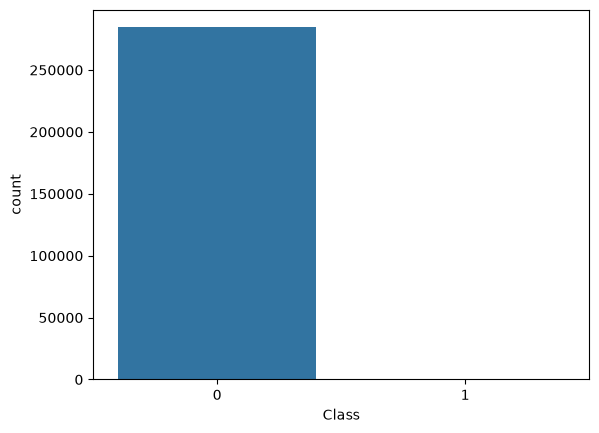

In [6]:
sns.countplot(df,x="Class")
plt.show()

In [7]:
df.isnull().sum().sum()

np.int64(0)

In [8]:
df.duplicated().sum() # we have 1081 duplicate dataset

np.int64(1081)

### Removing all duplicates

In [9]:
df.drop_duplicates(inplace=True)

### Plotting the heatmap of coorelation of all the columns

<Axes: >

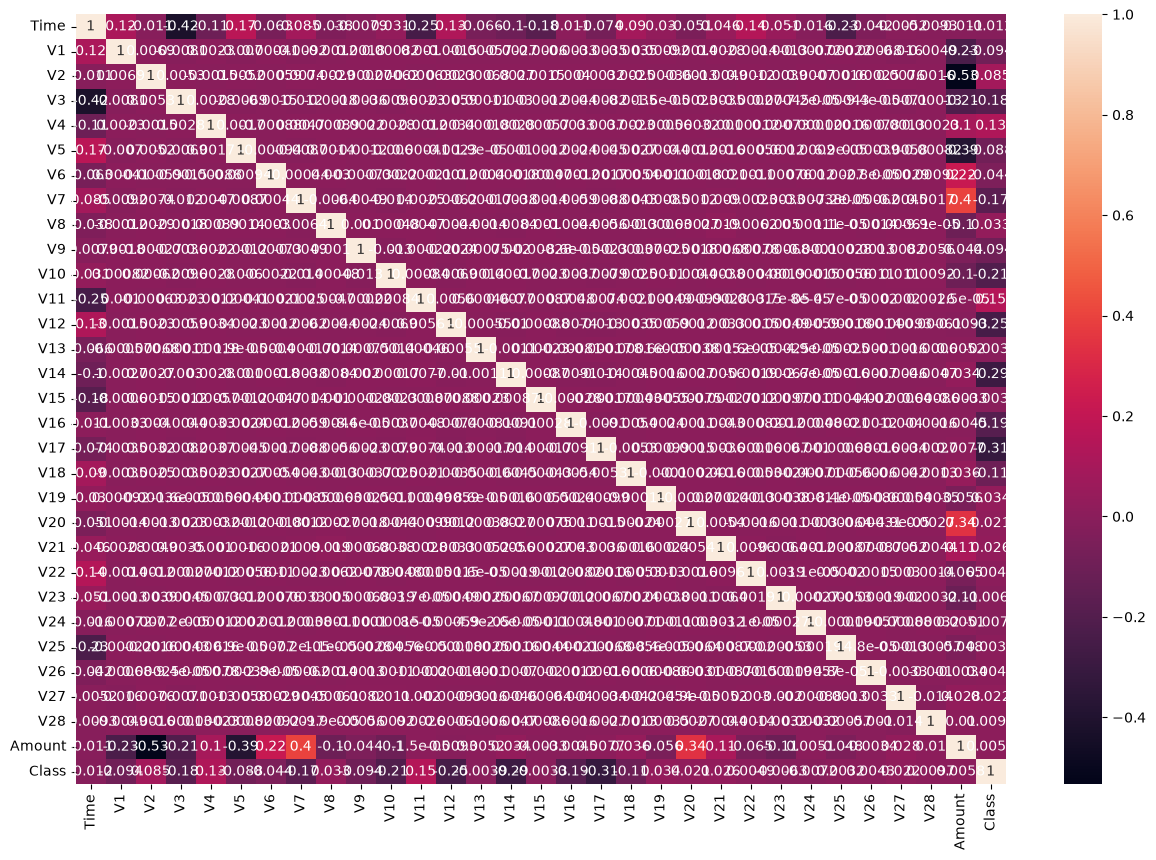

In [10]:
plt.figure(figsize=(15,10))
sns.heatmap(df.corr(),annot=True)

### Plotting Bar Chart of coorerlation of each column with Target(Class)

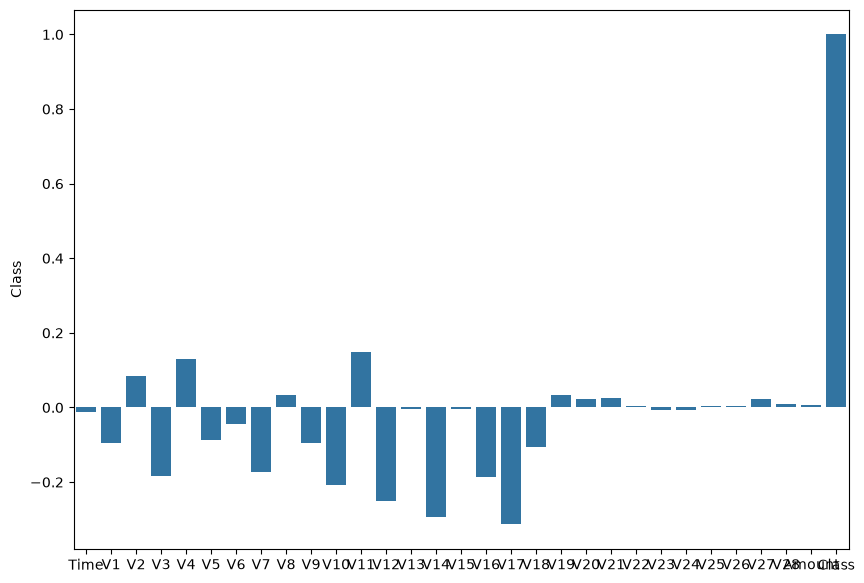

In [11]:
plt.figure(figsize=(10,7))
class_corr =df.corr()["Class"]
sns.barplot(class_corr)
plt.show()

### Selecting the top 50% columns that most coorelated with target columns

In [12]:
most_corr_columns = class_corr[abs(class_corr) > abs(class_corr).quantile(0.5)]
most_corr_columns

V1      -0.094486
V2       0.084624
V3      -0.182322
V4       0.129326
V5      -0.087812
V7      -0.172347
V9      -0.094021
V10     -0.206971
V11      0.149067
V12     -0.250711
V14     -0.293375
V16     -0.187186
V17     -0.313498
V18     -0.105340
Class    1.000000
Name: Class, dtype: float64

### Dividing data into X and Y

In [13]:
X=df[most_corr_columns.index].drop(columns="Class")
Y= df["Class"]

### Dividing Data into train and test

In [14]:
x_train,x_test,y_train,y_test =train_test_split(X,Y,stratify=Y,test_size=0.2,random_state=25)

In [15]:
print("Training Size: ",x_train.shape[0])
print("Testing Size: ",x_test.shape[0])

Training Size:  226980
Testing Size:  56746


### Checking class distribution in test and train

In [16]:
print("Training Class Distribution: ",y_train.value_counts())
print("Testing Class Distribution: ",y_test.value_counts())

Training Class Distribution:  Class
0    226602
1       378
Name: count, dtype: int64
Testing Class Distribution:  Class
0    56651
1       95
Name: count, dtype: int64


### Training Logistic Regression model without any sampling

In [17]:
model1= LogisticRegression()
model1.fit(x_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

### Checking this model accuracy on training and testing

In [18]:
y_train_pred_1 = model1.predict(x_train)
y_test_pred_1 = model1.predict(x_test)
print("Training Accuracy: ",accuracy_score(y_train,y_train_pred_1)*100)
print("Test Accuracy: ",accuracy_score(y_test,y_test_pred_1)*100)

Training Accuracy:  99.91805445413692
Test Accuracy:  99.91541254009093


### Seeing the true picture of accuracy

In [19]:
print("Training Confusion Matrix: \n")
print(confusion_matrix(y_train,y_train_pred_1))
print("="*50)
print("Testing Confusion Matrix:\n ")
print(confusion_matrix(y_test,y_test_pred_1))

Training Confusion Matrix: 

[[226571     31]
 [   155    223]]
Testing Confusion Matrix:
 
[[56643     8]
 [   40    55]]


### Balancing dataset using undersampling

In [20]:
under_sampler = RandomUnderSampler(random_state=25)
balanced_x_train,balanced_y_train = under_sampler.fit_resample(x_train,y_train)

### Checking class distribution after undersampling

In [21]:
print(balanced_y_train.value_counts())

Class
0    378
1    378
Name: count, dtype: int64


### training Logistic Regression on this undersampling dataset

In [22]:
model2 = LogisticRegression(random_state=25)
model2.fit(balanced_x_train,balanced_y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",25
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solve

In [23]:
y_train_pred_2 = model2.predict(x_train)
y_test_pred_2 = model2.predict(x_test)
print("Training Accuracy: ",accuracy_score(y_train,y_train_pred_2)*100)
print("Test Accuracy: ",accuracy_score(y_test,y_test_pred_2)*100)

Training Accuracy:  97.22883073398538
Test Accuracy:  97.20861382300075


In [24]:
print("Training Confusion Matrix: \n")
print(confusion_matrix(y_train,y_train_pred_2))
print("="*50)
print("Testing Confusion Matrix:\n ")
print(confusion_matrix(y_test,y_test_pred_2))

Training Confusion Matrix: 

[[220348   6254]
 [    36    342]]
Testing Confusion Matrix:
 
[[55076  1575]
 [    9    86]]


In [25]:
df['Class'].value_counts()

Class
0    283253
1       473
Name: count, dtype: int64

### Use Oversampling techiniques and KNN models with other techniques and make the best possible model

In [26]:
# ============================================================
# FINAL MODEL: SMOTE + LOGISTIC REGRESSION + KNN
# ============================================================

from imblearn.over_sampling import SMOTE
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score
)
import pandas as pd

# ------------------------------------------------------------
# 1. OVERSAMPLING USING SMOTE
# ------------------------------------------------------------

smote = SMOTE(random_state=25)

smote_x_train, smote_y_train = smote.fit_resample(
    x_train,
    y_train
)

print("Class distribution after SMOTE:")
print(smote_y_train.value_counts())


# ------------------------------------------------------------
# 2. LOGISTIC REGRESSION WITH SMOTE
# ------------------------------------------------------------

model3 = LogisticRegression(
    max_iter=1000,
    random_state=25
)

model3.fit(
    smote_x_train,
    smote_y_train
)

y_test_pred_3 = model3.predict(x_test)

print("\n===== SMOTE + LOGISTIC REGRESSION =====")

print(
    "Accuracy:",
    accuracy_score(y_test, y_test_pred_3) * 100,
    "%"
)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_test_pred_3))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_test_pred_3,
        digits=4
    )
)


# ------------------------------------------------------------
# 3. KNN MODEL
# ------------------------------------------------------------

# Scaling data because KNN is distance based

scaler = StandardScaler()

knn_x_train = scaler.fit_transform(
    balanced_x_train
)

knn_x_test = scaler.transform(
    x_test
)

# Create KNN model
model4 = KNeighborsClassifier(
    n_neighbors=5
)

# Train KNN
model4.fit(
    knn_x_train,
    balanced_y_train
)

# Prediction
y_test_pred_4 = model4.predict(
    knn_x_test
)

print("\n===== KNN MODEL =====")

print(
    "Accuracy:",
    accuracy_score(y_test, y_test_pred_4) * 100,
    "%"
)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_test_pred_4))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_test_pred_4,
        digits=4
    )
)


# ------------------------------------------------------------
# 4. COMPARE ALL MODELS
# ------------------------------------------------------------

results = pd.DataFrame({

    "Model": [
        "Logistic Regression - Original",
        "Logistic Regression - Undersampling",
        "Logistic Regression - SMOTE",
        "KNN - Undersampling"
    ],

    "Accuracy": [
        accuracy_score(y_test, y_test_pred_1),
        accuracy_score(y_test, y_test_pred_2),
        accuracy_score(y_test, y_test_pred_3),
        accuracy_score(y_test, y_test_pred_4)
    ],

    "Precision": [
        precision_score(y_test, y_test_pred_1),
        precision_score(y_test, y_test_pred_2),
        precision_score(y_test, y_test_pred_3),
        precision_score(y_test, y_test_pred_4)
    ],

    "Recall": [
        recall_score(y_test, y_test_pred_1),
        recall_score(y_test, y_test_pred_2),
        recall_score(y_test, y_test_pred_3),
        recall_score(y_test, y_test_pred_4)
    ],

    "F1 Score": [
        f1_score(y_test, y_test_pred_1),
        f1_score(y_test, y_test_pred_2),
        f1_score(y_test, y_test_pred_3),
        f1_score(y_test, y_test_pred_4)
    ]
})


# Convert values into percentage
results[
    ["Accuracy", "Precision", "Recall", "F1 Score"]
] = results[
    ["Accuracy", "Precision", "Recall", "F1 Score"]
] * 100


# Display comparison
print("\n===== MODEL COMPARISON =====")

print(
    results.round(2)
)

Class distribution after SMOTE:
Class
0    226602
1    226602
Name: count, dtype: int64

===== SMOTE + LOGISTIC REGRESSION =====
Accuracy: 97.02005427695343 %

Confusion Matrix:
[[54969  1682]
 [    9    86]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9998    0.9703    0.9849     56651
           1     0.0486    0.9053    0.0923        95

    accuracy                         0.9702     56746
   macro avg     0.5242    0.9378    0.5386     56746
weighted avg     0.9982    0.9702    0.9834     56746


===== KNN MODEL =====
Accuracy: 97.80601275860855 %

Confusion Matrix:
[[55418  1233]
 [   12    83]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9998    0.9782    0.9889     56651
           1     0.0631    0.8737    0.1176        95

    accuracy                         0.9781     56746
   macro avg     0.5314    0.9260    0.5533     56746
weighted avg     0.9982    0.9781    0.98